In [1]:
import sys, os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import fisher_exact
from matplotlib.patches import Patch
from scipy.stats import zscore
from scipy.stats import linregress

In [36]:
sys.path.append('/data/bbg/projects/lung_duplex/notebooks/fullcohortnormal/')
from consensus_variables import *
from common_functions import *

## FUNCTIONS

In [57]:
def load_omegas_n_mutden(deepcsa_run_dir, gene_order):
    omegas_df = pd.read_table(f"{deepcsa_run_dir}/omega/all_omegas.tsv", sep='\t')
    omegas_df = omegas_df[
          (omegas_df['sample'] == 'all_samples')
        & (omegas_df['impact'] == 'nonsense')
        # & (omegas_df['impact'] == 'truncating')
        & (omegas_df['gene'].isin(gene_order))
    ]


    mut_den_df = pd.read_table(f"{deepcsa_run_dir}/mutdensity/all_mutdensities.tsv", sep='\t')
    mut_den_df = mut_den_df[
          (mut_den_df['SAMPLE_ID'] == 'all_samples')
        & (mut_den_df['MUTTYPES'] == 'DELETION-INSERTION') 
        & (mut_den_df['REGIONS'] == 'protein_affecting') 
        & (mut_den_df['GENE'].isin(gene_order))
    ]
    return omegas_df, mut_den_df

In [58]:
def analyze_mutation_density_and_omega(mut_den_df, omegas_df, dataset_name = ''):

    # Create barplots for mutation density and omega values
    fig, axes = plt.subplots(2, 2, figsize=(6, 5))

    # Sort dataframes by mutation density in decreasing order
    mut_den_df_sorted = mut_den_df.sort_values(by='MUTDENSITY_MB', ascending=False)
    omegas_df_sorted = omegas_df.set_index('gene').reindex(mut_den_df_sorted['GENE']).reset_index()
    omegas_df_sorted.rename(columns={'GENE': 'gene'}, inplace=True)

    mut_den_df_sorted = mut_den_df_sorted.head(30)
    omegas_df_sorted = omegas_df_sorted.head(30)

    # Barplot for mutation density
    ax1 = axes[0,0]
    sns.barplot(data=mut_den_df_sorted, x='GENE', y='MUTDENSITY_MB', ax=ax1)
    ax1.set_title('Mutation Density by Gene (DELETION-INSERTION)')
    ax1.set_xlabel('Gene')
    ax1.set_ylabel('Mutation Density (MB)')
    ax1.tick_params(axis='x', rotation=70)

    # Barplot for omega values with distinction for significance
    ax2 = axes[0,1]
    omegas_df_sorted['significance'] = omegas_df_sorted['pvalue'] < 0.05
    sns.barplot(data=omegas_df_sorted, x='gene', y='dnds', hue='significance', ax=ax2, palette={True: 'red', False: 'blue'})
    ax2.set_title('dN/dS (Omega) by Gene (Truncating)')
    ax2.set_xlabel('Gene')
    ax2.set_ylabel('dN/dS')
    ax2.tick_params(axis='x', rotation=70)

    # Merge dataframes for correlation analysis
    merged_df = pd.merge(mut_den_df[['GENE', 'MUTDENSITY_MB']], 
                         omegas_df[['gene', 'dnds', 'pvalue']], 
                         left_on='GENE', right_on='gene', how='inner')

    # Scatterplot for correlation with distinction for significance
    ax3 = axes[1,0]
    merged_df['significance'] = merged_df['pvalue'] < 0.05
    sns.scatterplot(data=merged_df, x='MUTDENSITY_MB', y='dnds',
                        hue='significance', style='significance',
                        ax=ax3, palette={True: 'red', False: 'blue'},
                        markers={True: 'o', False: 'X'}, s=20)
    ax3.set_xlabel('Mutation Density (DELETION-INSERTION)')
    ax3.set_ylabel('dN/dS (Truncating)')
    ax3.set_title('Correlation: Mutation Density vs dN/dS')

    # Add regression line
    slope, intercept, r_value, p_value, std_err = linregress(merged_df['MUTDENSITY_MB'], merged_df['dnds'])
    line = slope * merged_df['MUTDENSITY_MB'] + intercept
    ax3.plot(merged_df['MUTDENSITY_MB'], line, 'r', alpha=0.8)
    ax3.text(0.05, 0.95, f'R² = {r_value**2:.3f}\np = {p_value:.3e}', 
             transform=ax3.transAxes, verticalalignment='top', 
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
             fontsize = 5
             )

    # Annotate points with gene names
    for i, row in merged_df.iterrows():
        ax3.annotate(row['GENE'], (row['MUTDENSITY_MB'], row['dnds']), 
                    xytext=(2, 2), textcoords='offset points', fontsize=5,
                    alpha=0.7)

    # Summary statistics table
    ax4 = axes[1,1]
    ax4.axis('off')
    summary_stats = pd.DataFrame({
        'Metric': ['Mean Mut Density', 'Std Mut Density', 'Mean dN/dS', 'Std dN/dS', 'Correlation (r)', 'P-value'],
        'Value': [f'{merged_df["MUTDENSITY_MB"].mean():.3f}',
                  f'{merged_df["MUTDENSITY_MB"].std():.3f}',
                  f'{merged_df["dnds"].mean():.3f}',
                  f'{merged_df["dnds"].std():.3f}',
                  f'{r_value:.3f}',
                  f'{p_value:.3e}']
    })
    table = ax4.table(cellText=summary_stats.values, colLabels=summary_stats.columns,
                      cellLoc='center', loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(6)
    table.scale(1.2, 1.5)
    ax4.set_title('Summary Statistics')
    plt.tight_layout()
    plt.savefig(f'plots/{dataset_name}_mutdensityIndels_vs_omega_truncating.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"Number of genes in analysis: {len(merged_df)}")
    print(f"Correlation coefficient: {r_value:.3f}")
    print(f"P-value: {p_value:.3e}")
    print(f"R-squared: {r_value**2:.3f}")

    # Alternative barplot for mutation density using z-scores
    fig, ax = plt.subplots(figsize=(6, 4))

    # Compute z-scores for mutation densities
    mut_den_df_sorted['zscore_MUTDENSITY_MB'] = zscore(mut_den_df_sorted['MUTDENSITY_MB'])

    # Barplot for z-scores of mutation density
    sns.barplot(data=mut_den_df_sorted, x='GENE', y='zscore_MUTDENSITY_MB', ax=ax, color='skyblue')
    ax.set_title('Z-scores of Mutation Density by Gene (DELETION-INSERTION)')
    ax.set_xlabel('Gene')
    ax.set_ylabel('Z-score of Mutation Density')
    ax.tick_params(axis='x', rotation=70)

    plt.tight_layout()
    plt.show()

## Bladder

In [59]:
deepcsa_run_dir = '/data/bbg/nobackup/bladder_ts/results/2025-09-24_deepCSA_updated_run'
# samples_names, group_names, all_unit_names, all_units_groups = load_samples_info(deepcsa_run_dir)

In [60]:
gene_order = ["KMT2D","EP300","ARID1A","CREBBP","NOTCH2","KMT2C","STAG2","RB1",
                   "RBM10","KDM6A","TP53","FGFR3","CDKN1A","FOXQ1",
                   "PIK3CA","TERT"
                  ]

In [61]:
omegas_df, mut_den_df = load_omegas_n_mutden(deepcsa_run_dir, gene_order)

In [62]:
omegas_df[omegas_df['pvalue'] < 0.05].sort_values(by='dnds', ascending=False)

,gene,sample,impact,mutations,dnds,pvalue,lower,upper
6831,RBM10,all_samples,nonsense,1336,42.018750,0.000000,36.727914,48.166211
5878,KDM6A,all_samples,nonsense,1125,37.550000,0.000000,32.807092,43.023022
6995,KMT2D,all_samples,nonsense,4678,22.362488,0.000000,20.049338,24.983948
5909,ARID1A,all_samples,nonsense,1606,17.915625,0.000000,15.660482,20.514502
6476,CDKN1A,all_samples,nonsense,181,16.206250,0.000000,13.174396,19.878735
6882,STAG2,all_samples,nonsense,655,15.912402,0.000000,13.680009,18.538135
6291,EP300,all_samples,nonsense,407,5.456836,0.000000,4.556565,6.535327
7125,NOTCH2,all_samples,nonsense,216,4.885155,0.000000,4.005580,5.942284
6787,TP53,all_samples,nonsense,40,3.529688,0.000000,2.448690,4.965234
6299,CREBBP,all_samples,nonsense,224,3.323486,0.000000,2.701399,4.082153


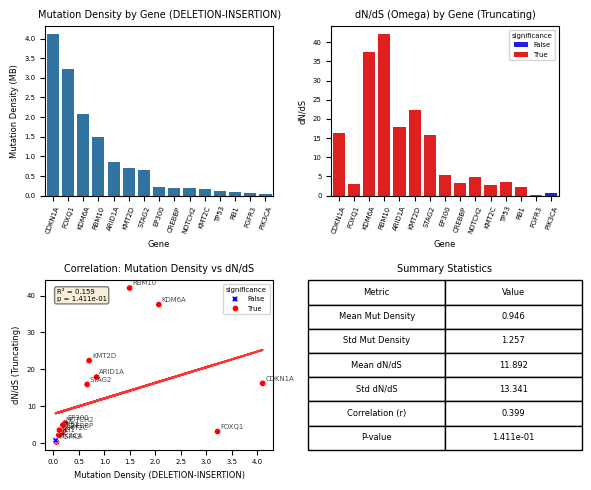

Number of genes in analysis: 15
Correlation coefficient: 0.399
P-value: 1.411e-01
R-squared: 0.159


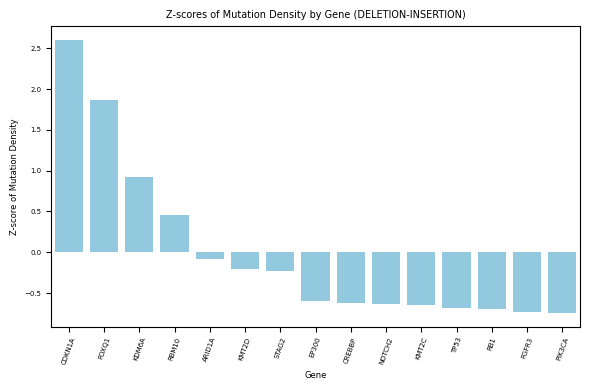

In [63]:
# Call the function with the required dataframes
analyze_mutation_density_and_omega(mut_den_df, omegas_df, 'Bladder_nonsense')

## Kidney

In [ ]:
deepcsa_run_dir = f"/data/bbg/nobackup/prominent/kidney/pancancerpanel/2025-09-17_LCMs_all"
gene_order = ['ACVR2A', 'AJUBA', 'AKAP9', 'AKT1', 'ALK', 'AMER1', 'APC', 'AR', 'ARHGAP35',
                    'ARID1A', 'ARID1B', 'ARID2', 'ASXL1', 'ATM', 'ATR', 'ATRX', 'AXIN1', 'B2M',
                    'BAP1', 'BCL2', 'BCOR', 'BIRC6', 'BRAF', 'BRCA1', 'BRCA2', 'BTG1', 'BTG2',
                    'CARD11', 'CASP8', 'CBFB', 'CBL', 'CCND1', 'CDH1', 'CDH10', 'CDH11', 'CDK12',
                    'CDKN1A', 'CDKN1B', 'CDKN2A', 'CHD4', 'CHEK2', 'CREBBP', 'CSMD3', 'CTCF',
                    'CTNNA2', 'CTNNB1', 'CTNND2', 'CUL3', 'CUX1', 'CYLD', 'DCC', 'DDX3X', 'DICER1',
                    'DNMT3A', 'EGFR', 'ELF3', 'EP300', 'ERBB2', 'ERBB3', 'ERBB4', 'ERCC2', 'ESR1',
                    'EZH2', 'FAM135B', 'FAT1', 'FAT3', 'FAT4', 'FBXW7', 'FGFR2', 'FGFR3', 'FLT3',
                    'FOXA1', 'FOXA2', 'FOXQ1', 'GATA3', 'GNA13', 'GNAQ', 'GNAS', 'H3-3A', 'HRAS',
                    'ID3', 'IDH1', 'IDH2', 'IRF4', 'JAK1', 'JAK2', 'KDM5C', 'KDM6A', 'KDR', 'KEAP1',
                    'KIT', 'KMT2A', 'KMT2B', 'KMT2C', 'KMT2D', 'KRAS', 'LRP1B', 'LZTR1', 'MAP2K1',
                    'MAP2K4', 'MAP3K1', 'MAX', 'MECOM', 'MED12', 'MEN1', 'MET', 'MGA', 'MSH2', 'MSH6',
                    'MTOR', 'MYC', 'MYD88', 'NCOR1', 'NCOR2', 'NF1', 'NF2', 'NFE2L2', 'NOTCH1', 'NOTCH2',
                    'NOTCH3', 'NPM1', 'NRAS', 'NSD1', 'P2RY8', 'PABPC1', 'PBRM1', 'PCBP1', 'PHF6', 'PIGR',
                    'PIK3CA', 'PIK3R1', 'PIM1', 'POLE', 'POLQ', 'PPM1D', 'PPP2R1A', 'PPP6C', 'PRDM1', 'PREX2',
                    'PRKCB', 'PTCH1', 'PTEN', 'PTPN11', 'PTPRB', 'PTPRD', 'RAC1', 'RAD21', 'RB1', 'RBM10',
                    'RET', 'RGS7', 'RHOA', 'RNF43', 'RPL22', 'RUNX1', 'SETBP1', 'SETD2', 'SF3B1', 'SGK1',
                    'SMAD2', 'SMAD4', 'SMARCA4', 'SOCS1', 'SOX9', 'SPEN', 'SPOP', 'SRSF2', 'STAG2', 'STAT3',
                    'STK11', 'SUZ12', 'TBX3', 'TCF7L2', 'TENT5C', 'TERT', 'TERTpromoter', 'TET2', 'TGFBR2',
                    'TMSB4X', 'TNFRSF14', 'TP53', 'TP63', 'TRRAP', 'TSC1', 'TSC2', 'U2AF1', 'USP6', 'VHL',
                    'WT1', 'ZC3H12A', 'ZEB1', 'ZFHX3', 'ZMYM3']


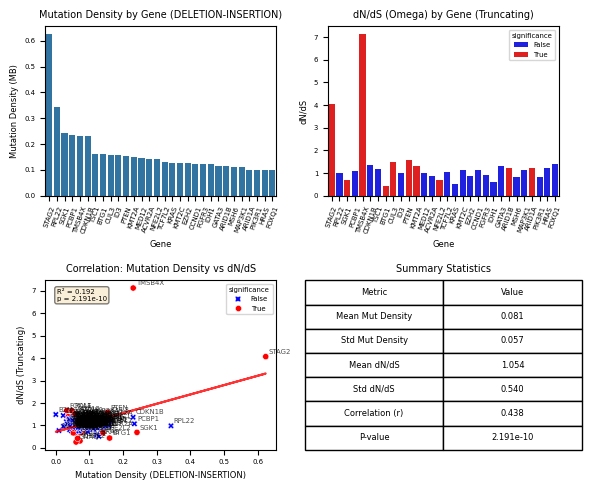

Number of genes in analysis: 192
Correlation coefficient: 0.438
P-value: 2.191e-10
R-squared: 0.192


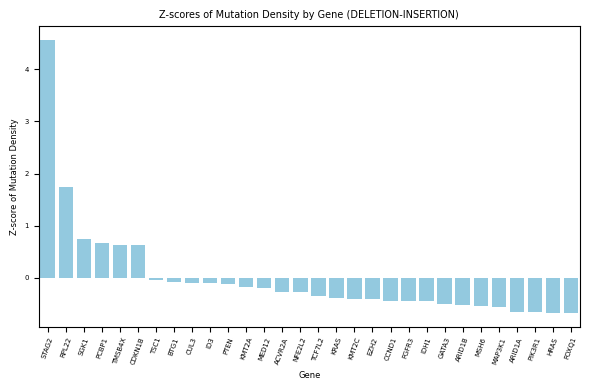

In [ ]:
omegas_df, mut_den_df = load_omegas_n_mutden(deepcsa_run_dir, gene_order)
omegas_df[omegas_df['pvalue'] < 0.05].sort_values(by='dnds', ascending=False)
# Call the function with the required dataframes
analyze_mutation_density_and_omega(mut_den_df, omegas_df, 'Kidney')

## Kidney Bulk

In [55]:
deepcsa_run_dir = f"/data/bbg/nobackup/prominent/kidney/deepCSA/kidneypanel/2025-09-19_bulk"
gene_order = ['ARID1A', 'BAP1', 'MTOR', 'PBRM1', 'PIK3CA', 'PTEN', 'SETD2', 'TP53', 'VHL']

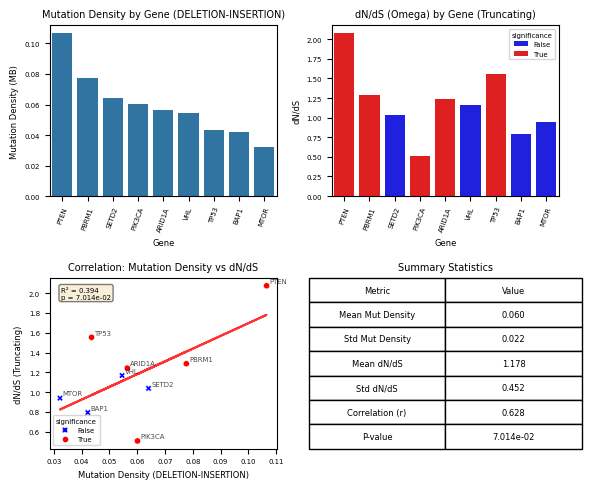

Number of genes in analysis: 9
Correlation coefficient: 0.628
P-value: 7.014e-02
R-squared: 0.394


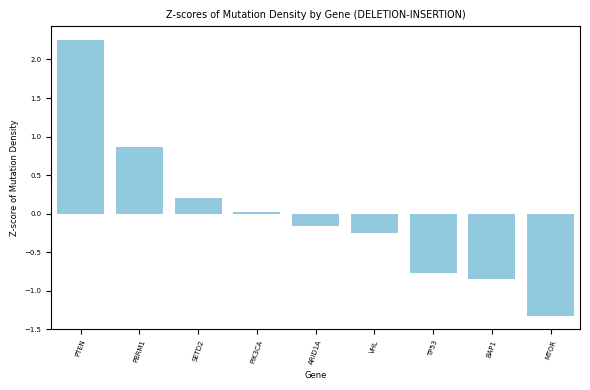

In [56]:
omegas_df, mut_den_df = load_omegas_n_mutden(deepcsa_run_dir, gene_order)
omegas_df[omegas_df['pvalue'] < 0.05].sort_values(by='dnds', ascending=False)
# Call the function with the required dataframes
analyze_mutation_density_and_omega(mut_den_df, omegas_df, 'Kidney_bulk')

## Lung

In [50]:
gene_order = ['ARID1A', 'ARID2', 'ATM',
               'BRAF', 'CDKN2A', 'CDKN2B', 'CHEK2', 'CTNNB1', 'EGFR', 'ERBB2', 'ERBB4', 'FAT1', 'KEAP1',
               'KMT2D', 'KRAS', 'MAX', 'NF1', 'NFE2L2', 'NOTCH1', 'PIK3CA', 'PTEN', 'RB1', 'SETBP1', 'SETD2',
               'SMAD4', 'SMARCA4', 'STK11', 'TP53']

In [51]:
from PEACE_specific_variables import *
samples_names, group_names, all_unit_names, all_units_groups = load_samples_info(deepcsa_run_dir)

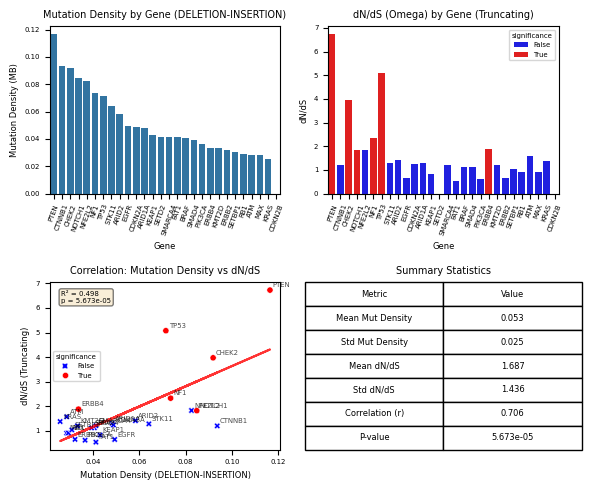

Number of genes in analysis: 26
Correlation coefficient: 0.706
P-value: 5.673e-05
R-squared: 0.498


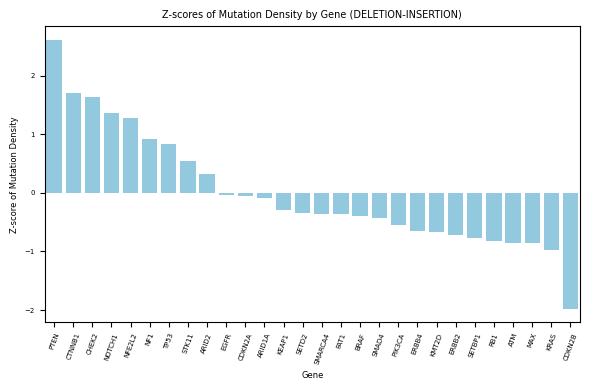

In [52]:
omegas_df, mut_den_df = load_omegas_n_mutden(deepcsa_run_dir, gene_order)
omegas_df[omegas_df['pvalue'] < 0.05].sort_values(by='dnds', ascending=False)
# Call the function with the required dataframes
analyze_mutation_density_and_omega(mut_den_df, omegas_df, 'PEACE')

In [41]:
from TRACERx_specific_variables import *
samples_names, group_names, all_unit_names, all_units_groups = load_samples_info(deepcsa_run_dir)

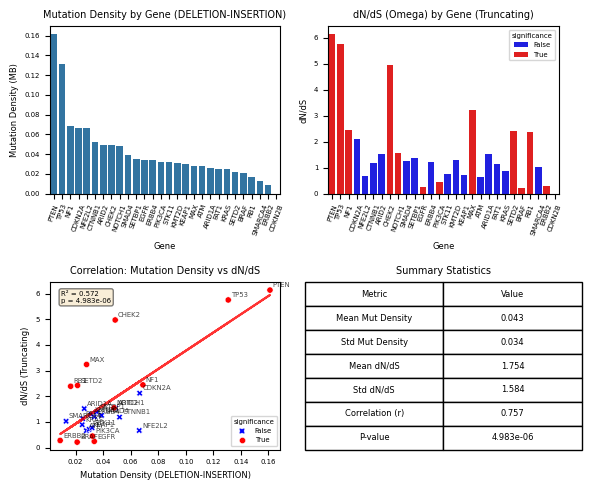

Number of genes in analysis: 27
Correlation coefficient: 0.757
P-value: 4.983e-06
R-squared: 0.572


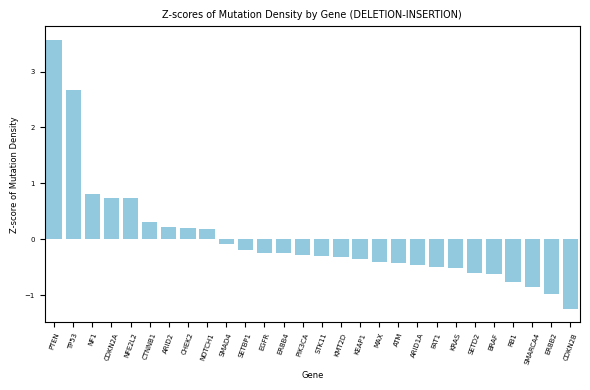

In [42]:
omegas_df, mut_den_df = load_omegas_n_mutden(deepcsa_run_dir, gene_order)
omegas_df[omegas_df['pvalue'] < 0.05].sort_values(by='dnds', ascending=False)
# Call the function with the required dataframes
analyze_mutation_density_and_omega(mut_den_df, omegas_df, 'TRACERx')

In [53]:
from BDRE_specific_variables import *
samples_names, group_names, all_unit_names, all_units_groups = load_samples_info(deepcsa_run_dir)

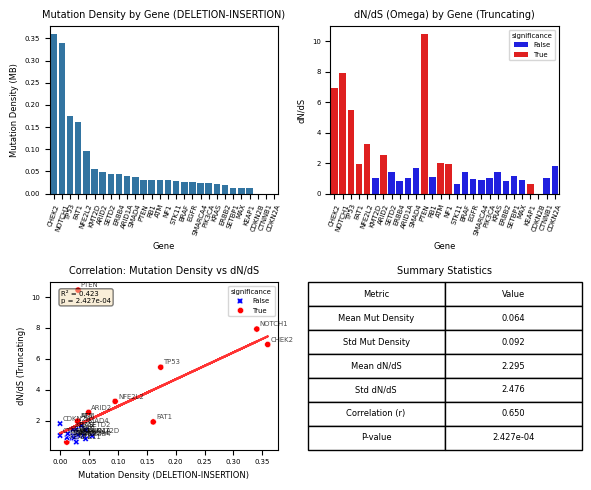

Number of genes in analysis: 27
Correlation coefficient: 0.650
P-value: 2.427e-04
R-squared: 0.423


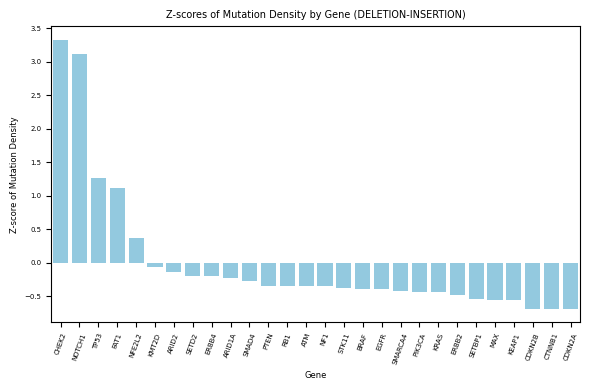

In [54]:
omegas_df, mut_den_df = load_omegas_n_mutden(deepcsa_run_dir, gene_order)
omegas_df[omegas_df['pvalue'] < 0.05].sort_values(by='dnds', ascending=False)
# Call the function with the required dataframes
analyze_mutation_density_and_omega(mut_den_df, omegas_df, 'BDRE')